In [22]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler,LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

In [31]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/titanic_data.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [30]:
df.shape

(891, 12)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [33]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [26]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [28]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [35]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [43]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_1889/2861725518.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [44]:
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)
    print("Column 'Cabin' dropped successfully.")
else:
    print("Column 'Cabin' not found. It might have been dropped already.")

Column 'Cabin' dropped successfully.


In [45]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [48]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Sex'].head()

,Sex
0,1
1,0
2,0
3,0
4,1


In [ ]:
df = pd.get_dummies(df, columns=['Embarked'])

In [58]:
print(df.head())

   PassengerId  Survived  Pclass  ... Embarked_C  Embarked_Q  Embarked_S
0            1         0       3  ...      False       False        True
1            2         1       1  ...       True       False       False
2            3         1       3  ...      False       False        True
3            4         1       1  ...      False       False        True
4            5         0       3  ...      False       False        True

[5 rows x 13 columns]


In [62]:
scaler=MinMaxScaler()
df['Age']=scaler.fit_transform(df[['Age']])
df['Fare']=scaler.fit_transform(df[['Fare']])
df[['Age','Fare']].head()

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


In [66]:
#Create a new feature 'Family Size' as SibSp+parch+1
df['FamilySize']=df['SibSp']+df['Parch']+1
print("FamilySize feature Created")
display(df[["SibSp","Parch","FamilySize"]].head())

FamilySize feature Created


,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [75]:
#Create a new feature IsAlone where 1 indicates travelling alone
df['IsAlone']=df['FamilySize'].apply(lambda x:1 if x==1 else 0)
print(" FamilySize and IsAlone is added Successfully")

 FamilySize and IsAlone is added Successfully


In [76]:
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Age']>=lower_bound)]
print('Outliers removed')

Outliers removed


In [77]:
print("Dataset shape After removing outlier: ",df.shape)

Dataset shape After removing outlier:  (891, 15)


In [78]:
drop_columns=['Name','Ticket']
df.drop(drop_columns,axis=1,inplace=True)
print("Columns dropped successfully")

Columns dropped successfully


In [79]:
#Display side-by-side comparison of raw vs processed dataset(first 10 row)
#Fefore vs After data comparison
print('After preprocessing')
display(df.head(10))

After preprocessing


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,1,0,3,1,0.271174,1,0,0.014151,False,False,True,2,0
1,2,1,1,0,0.472229,1,0,0.139136,True,False,False,2,0
2,3,1,3,0,0.321438,0,0,0.015469,False,False,True,1,1
3,4,1,1,0,0.434531,1,0,0.103644,False,False,True,2,0
4,5,0,3,1,0.434531,0,0,0.015713,False,False,True,1,1
5,6,0,3,1,0.367921,0,0,0.016510,False,True,False,1,1
6,7,0,1,1,0.673285,0,0,0.101229,False,False,True,1,1
7,8,0,3,1,0.019854,3,1,0.041136,False,False,True,5,0
8,9,1,3,0,0.334004,0,2,0.021731,False,False,True,3,0
9,10,1,2,0,0.170646,1,0,0.058694,True,False,False,2,0


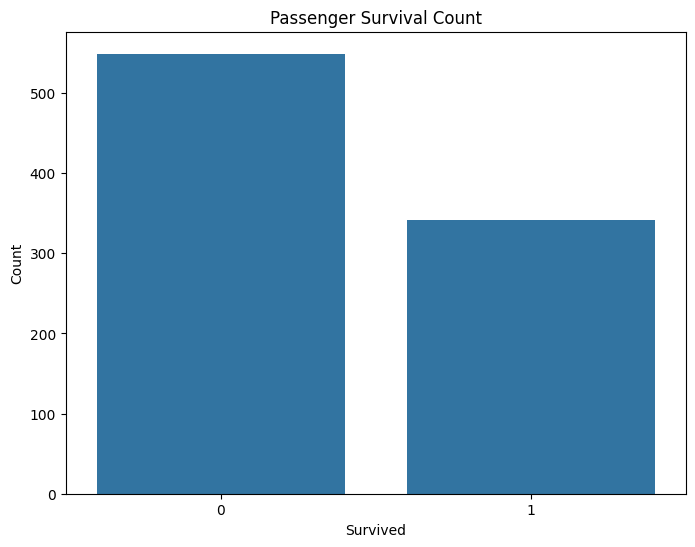

In [71]:
plt.figure(figsize=(8,6))
sns.countplot(x="Survived",data=df)
plt.title("Passenger Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

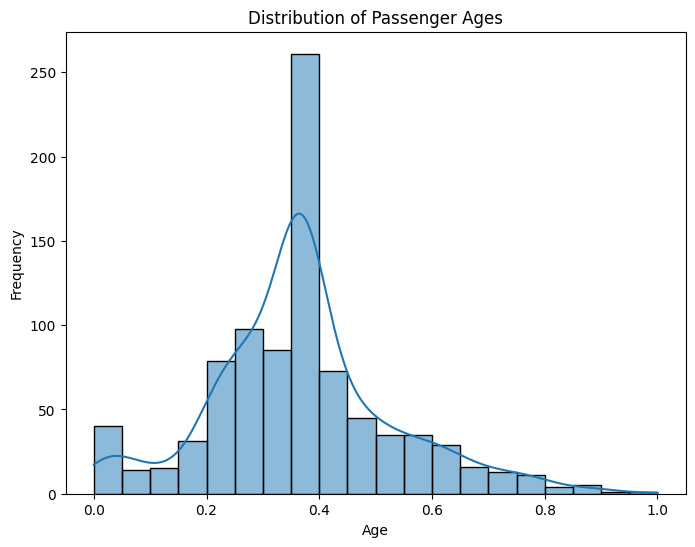

In [74]:
plt.figure(figsize=(8,6))
sns.histplot(df['Age'],bins=20,kde=True)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

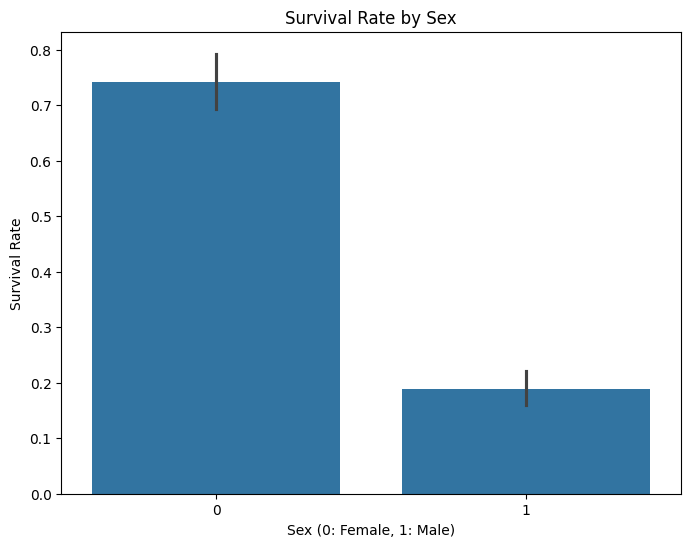

In [81]:
plt.figure(figsize=(8,6))
sns.barplot(x='Sex',y='Survived',data=df)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex (0: Female, 1: Male)")
plt.ylabel("Survival Rate")
plt.show()